# Performance Benchmarking: VibeSpin Simulation Framework

This notebook benchmarks the VibeSpin simulation framework: throughput (sweeps/s), analysis overhead (energy, magnetization, correlation function $G(r)$, vorticity), and scaling across lattice sizes and update schemes.

## How to Use
1. Run all cells once to compile Numba kernels.
2. Re-run benchmark and plotting cells for stable timing values.
3. Use checkerboard updates for equilibrium studies and random updates for kinetics-focused studies.

## Objectives
1. Throughput: Measure sweeps/s scaling with system size $N = L^2$.
2. Analysis Overhead: Quantify thermodynamic, correlation-function, and vorticity costs.
3. Scaling Behavior: Validate near-$O(N)$ sweep scaling and expected $O(N \log N)$ trends in FFT-based correlation analysis.

In [30]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from tqdm.auto import tqdm

from models.clock_model import ClockSimulation
from models.ising_model import IsingSimulation
from models.xy_model import XYSimulation

%matplotlib inline
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.dpi'] = 100

## Benchmark Configuration

We define a helper function to measure throughput and analysis times.

Assumptions and rationale:
- Fixed seed gives reproducible comparisons across models.
- Analysis timings are averaged over multiple iterations to reduce noise.
- Larger lattices use fewer sweeps to keep notebook runtime reasonable.
- One sweep corresponds to approximately one attempted update per lattice site.
- Warm-up calls are used so Numba compile overhead is excluded from timing.

In [31]:
# --- Benchmark configuration -------------------------------------------------
SEED = 42
ANALYSIS_ITERS = 50
N_SWEEPS_MAP = {32: 200, 64: 200, 128: 200, 256: 50, 512: 50}

_model_names = [
    'Ising (Checkerboard)',
    'Ising (Random)',
    'XY (Checkerboard)',
    'XY (Random)',
    'Clock (Checkerboard)',
    'Clock (Random)',
]

_palette = [c['color'] for c in plt.rcParams['axes.prop_cycle']]
MODEL_COLORS = {name: _palette[i % len(_palette)] for i, name in enumerate(_model_names)}
MODEL_MARKERS = {
    'Ising (Checkerboard)': 'o',
    'Ising (Random)': 's',
    'XY (Checkerboard)': '^',
    'XY (Random)': 'D',
    'Clock (Checkerboard)': 'v',
    'Clock (Random)': 'P',
}
MODEL_LS = {name: '-' if 'Checkerboard' in name else '--' for name in _model_names}

In [32]:
def measure_performance(sim, sweeps=100, analysis_iters=50):
    """Measure sweeps/sec and analysis times for a simulation instance."""
    # Warm-up (triggers Numba JIT compilation; 3 iterations stabilise the instruction cache)
    for _ in range(3):
        sim.step()
        sim._get_energy()
        sim._calculate_correlation_function()
        if hasattr(sim, '_calculate_vorticity'):
            sim._calculate_vorticity()

    # 1. Sweep speed (Throughput)
    start = time.perf_counter()
    for _ in range(sweeps):
        sim.step()
    sweep_duration = time.perf_counter() - start
    sps = sweeps / sweep_duration

    # 2. Thermodynamic measurements (Energy + Magnetization)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._get_energy()
        sim._get_magnetization()
    thermo_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 3. Correlation function G(r) (FFT-based)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._calculate_correlation_function()
    corr_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 4. Vorticity (Topological defects)
    vort_ms = 0.0
    if hasattr(sim, '_calculate_vorticity'):
        start = time.perf_counter()
        for _ in range(analysis_iters):
            sim._calculate_vorticity()
        vort_ms = (time.perf_counter() - start) / analysis_iters * 1000

    return {'sps': sps, 'thermo_ms': thermo_ms, 'corr_ms': corr_ms, 'vort_ms': vort_ms}

## Execution

We benchmark six model variants (Ising, XY, Clock with checkerboard/random updates) across several lattice sizes.

For each model-size pair, the workflow is:
1. Warm-up to trigger JIT compilation and stabilize cache behavior.
2. Measure sweep throughput.
3. Measure analysis costs (thermodynamics, correlation function, vorticity where available).

Tip: total runtime depends on CPU and cache performance; use relative comparisons between curves, not absolute values alone.

In [33]:
sizes = [32, 64, 128, 256, 512]
model_configs = [
    (
        'Ising (Checkerboard)',
        lambda L: IsingSimulation(size=L, temp=2.269, update='checkerboard', seed=SEED),
    ),
    ('Ising (Random)', lambda L: IsingSimulation(size=L, temp=2.269, update='random', seed=SEED)),
    (
        'XY (Checkerboard)',
        lambda L: XYSimulation(size=L, temp=0.89, update='checkerboard', seed=SEED),
    ),
    ('XY (Random)', lambda L: XYSimulation(size=L, temp=0.89, update='random', seed=SEED)),
    (
        'Clock (Checkerboard)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, update='checkerboard', seed=SEED),
    ),
    (
        'Clock (Random)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, update='random', seed=SEED),
    ),
]

results = {name: {} for name, _ in model_configs}

for L in tqdm(sizes, desc="Lattice Sizes"):
    for name, constructor in model_configs:
        sim = constructor(L)
        n_sweeps = N_SWEEPS_MAP.get(L, 200 if L <= 128 else 50)
        metrics = measure_performance(sim, sweeps=n_sweeps, analysis_iters=ANALYSIS_ITERS)
        results[name][L] = metrics

Lattice Sizes:   0%|          | 0/5 [00:00<?, ?it/s]

## Visualization

### 1. Throughput (Sweeps/s)
Higher is better. This plot shows raw update speed as a function of system size.

How to read it:
- Vertical separation indicates constant-factor speed differences.
- Similar slope between curves suggests similar asymptotic complexity.
- Checkerboard updates are often faster due to better memory access patterns.

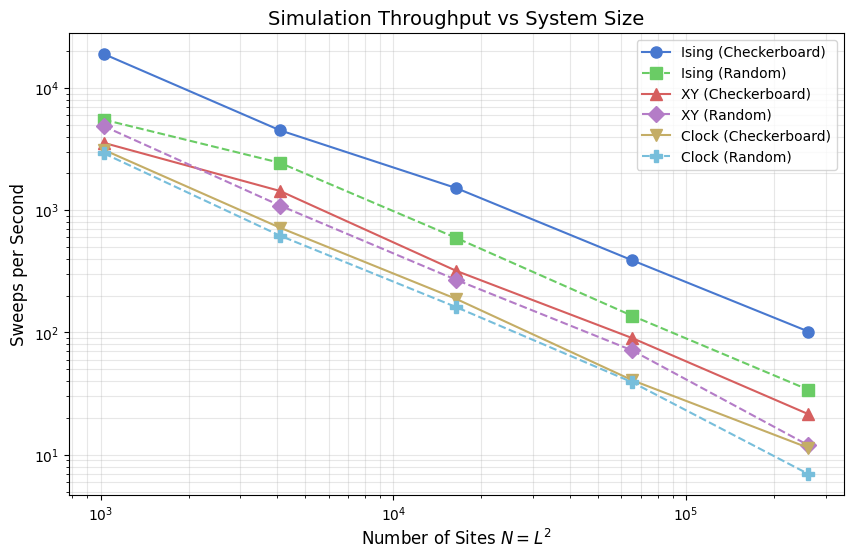

In [34]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    sps_vals = [results[name][L]['sps'] for L in L_vals]
    plt.loglog(
        N_vals, sps_vals,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name, markersize=8,
    )

plt.title('Simulation Throughput vs System Size', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Sweeps per Second', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

### 2. Analysis Costs
Lower is better. We compare:
- Thermodynamic measurements (energy + magnetization)
- Correlation function $G(r)$ (FFT-based)
- Vorticity detection (XY and Clock only)

How to read it:
- Growth rates indicate algorithmic scaling.
- Crossovers show when measurement cost starts dominating update cost.
- Ising has no vorticity cost and is omitted from that panel.

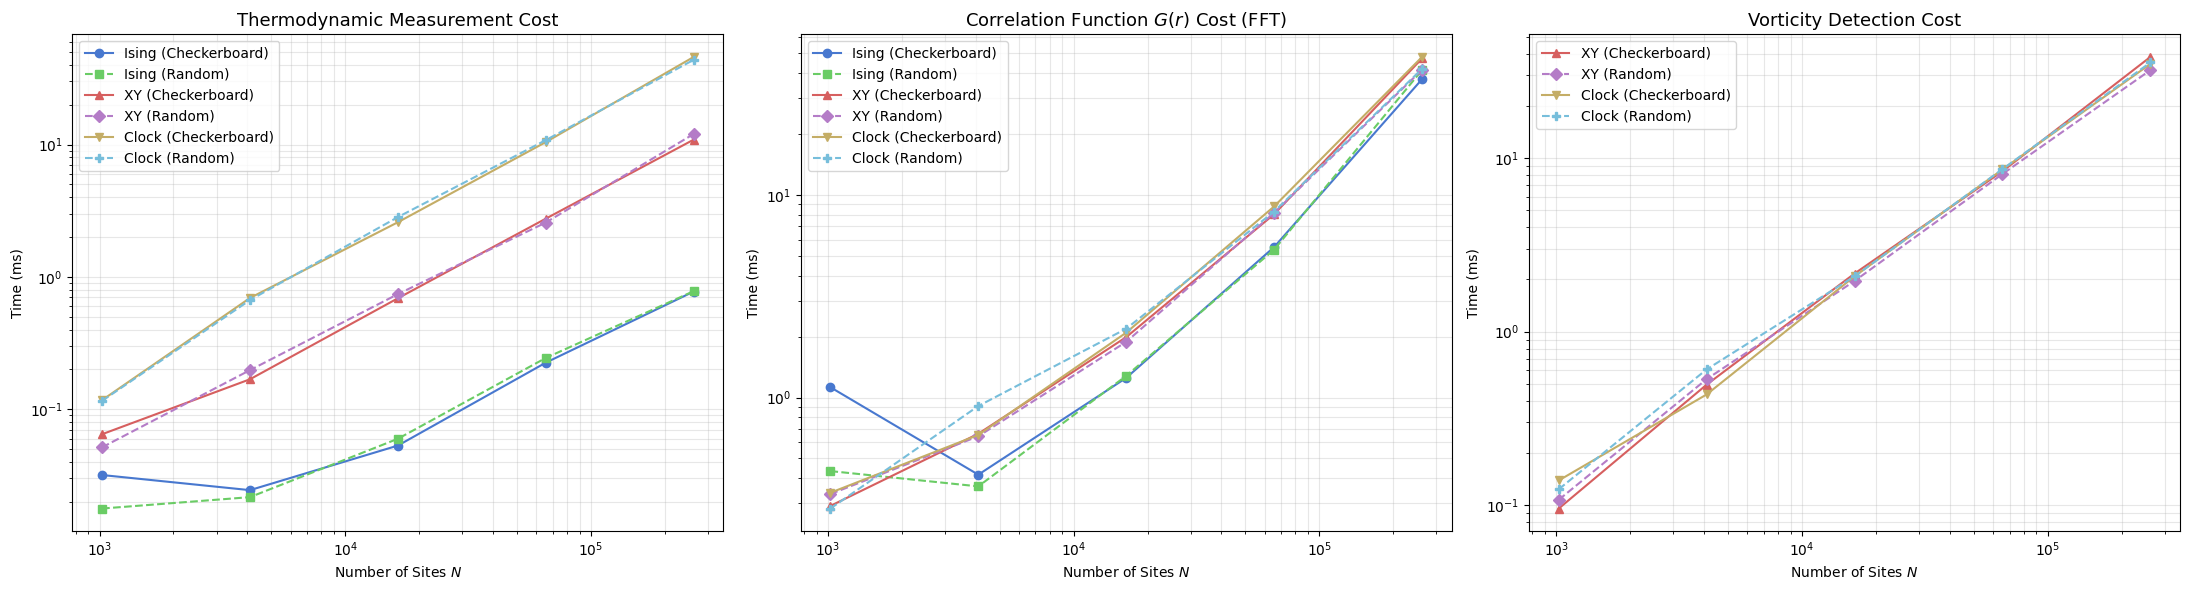

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    mkw = dict(
        marker=MODEL_MARKERS[name],
        linestyle=MODEL_LS[name],
        color=MODEL_COLORS[name],
        label=name,
    )

    # Thermo Cost
    thermo_vals = [results[name][L]['thermo_ms'] for L in L_vals]
    ax1.loglog(N_vals, thermo_vals, **mkw)

    # Correlation Cost
    corr_vals = [results[name][L]['corr_ms'] for L in L_vals]
    ax2.loglog(N_vals, corr_vals, **mkw)

    # Vorticity Cost (XY and Clock only)
    vort_vals = [results[name][L]['vort_ms'] for L in L_vals]
    if any(v > 0 for v in vort_vals):
        ax3.loglog(N_vals, vort_vals, **mkw)

ax1.set_title('Thermodynamic Measurement Cost', fontsize=13)
ax1.set_xlabel('Number of Sites $N$')
ax1.set_ylabel('Time (ms)')
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.set_title('Correlation Function $G(r)$ Cost (FFT)', fontsize=13)
ax2.set_xlabel('Number of Sites $N$')
ax2.set_ylabel('Time (ms)')
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

ax3.set_title('Vorticity Detection Cost', fontsize=13)
ax3.set_xlabel('Number of Sites $N$')
ax3.set_ylabel('Time (ms)')
ax3.grid(True, which="both", alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

### 3. Analysis Overhead Ratio
This ratio is

$$
\text{Overhead Ratio} = \frac{\text{Thermo} + \text{Corr} + \text{Vorticity}}{\text{Sweep time}}
$$

Interpretation:
- Ratio $< 1$: a full measurement set is cheaper than one sweep.
- Ratio $\approx 1$: measurement and dynamics costs are comparable.
- Ratio $> 1$: reduce measurement cadence for long runs.

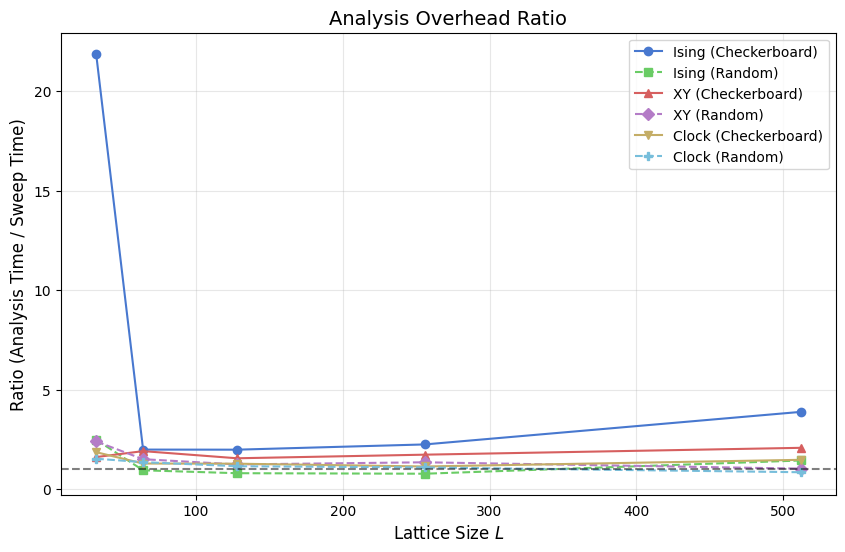

In [36]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    ratios = []
    for L in L_vals:
        m = results[name][L]
        sweep_ms = (1.0 / m['sps']) * 1000
        total_analysis_ms = m['thermo_ms'] + m['corr_ms'] + m['vort_ms']
        ratios.append(total_analysis_ms / sweep_ms)

    plt.plot(
        L_vals, ratios,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Analysis Overhead Ratio', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Ratio (Analysis Time / Sweep Time)', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Scaling Behavior Analysis

We fit a log-log regression for each model to estimate exponent $\alpha$ in

$$
T \propto N^\alpha
$$

where $T$ is time per sweep.

Interpretation:
- $\alpha \approx 1$: near-linear sweep scaling.
- $\alpha > 1$: superlinear overhead (often memory/cache effects at larger sizes).
- Deviations at very small or very large $N$ are common and not always algorithmic regressions.

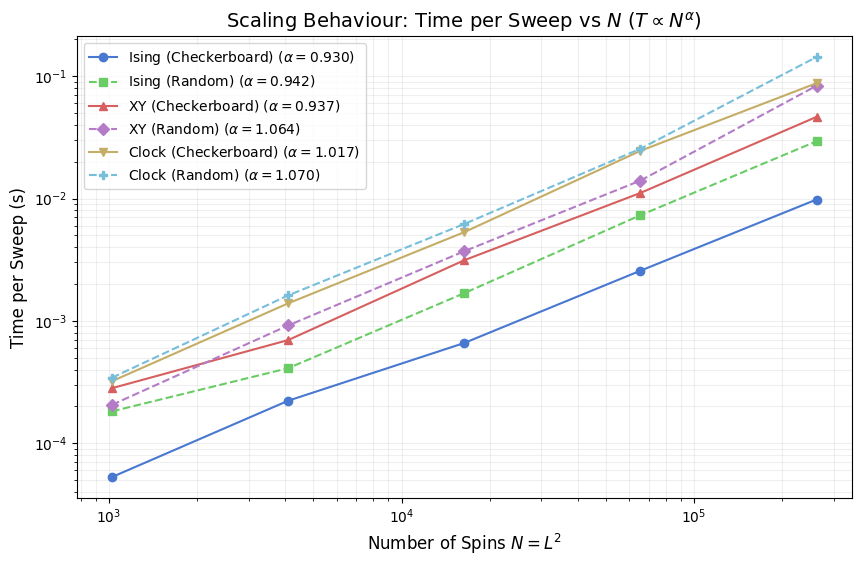

In [ ]:
def analyze_scaling(sizes, results):
    plt.figure(figsize=(10, 6))
    N_vals = [L*L for L in sizes]

    for name in results:
        sps = [results[name][L]['sps'] for L in sizes]
        time_per_sweep = [1.0/s for s in sps]

        # Log-log regression for exponent extraction
        log_N = np.log(N_vals)
        log_T = np.log(time_per_sweep)
        slope, intercept, r_value, p_value, std_err = linregress(log_N, log_T)

        plt.loglog(
            N_vals, time_per_sweep,
            marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
            label=rf"{name} ($\alpha={slope:.3f}$)",
        )

    plt.title(r'Scaling Behaviour: Time per Sweep vs $N$ ($T \propto N^\alpha$)', fontsize=14)
    plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
    plt.ylabel('Time per Sweep (s)', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

analyze_scaling(sizes, results)

## Time per Site (Update Cost)

Time per site, $T/N$, should remain approximately constant under ideal $O(N)$ scaling.

How to read it:
- Flat curve: stable per-site computational cost.
- Upward trend: increasing overhead with size (bandwidth/cache pressure).
- Downward trend at small sizes: fixed overhead amortization effects.

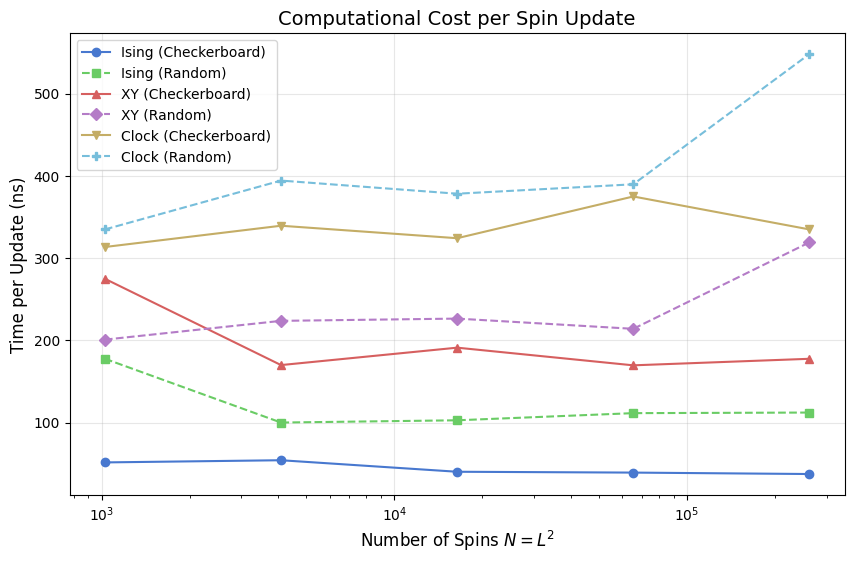

In [ ]:
plt.figure(figsize=(10, 6))
for name in results:
    N_vals = [L*L for L in sizes]
    sps = [results[name][L]['sps'] for L in sizes]
    tps = [(1.0/s)/N for s, N in zip(sps, N_vals, strict=False)]
    plt.semilogx(
        N_vals, [t*1e9 for t in tps],
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Computational Cost per Spin Update', fontsize=14)
plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
plt.ylabel('Time per Update (ns)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary Table

This table reports metrics at the largest lattice size tested.

Use it as a quick decision aid:
- Highest sweeps/s for raw simulation speed.
- Lowest thermodynamic, correlation-function, and vorticity times for analysis-heavy workflows.
- Best trade-off depends on whether your workload is update-bound or analysis-bound.

In [ ]:
L_max = sizes[-1]
print(f"Performance metrics for L = {L_max} (N = {L_max*L_max})")
print("-" * 85)
print(
    f"{'Model':<25} | {'Sweeps/s':>12} | {'Thermo (ms)':>12} | "
    f"{'G(r) (ms)':>12} | {'Vort (ms)':>12}"
)
print("-" * 85)

for name in results:
    m = results[name][L_max]
    vort_str = f"{m['vort_ms']:>12.3f}" if m['vort_ms'] > 0 else f"{'N/A':>12}"
    print(
        f"{name:<25} | {m['sps']:>12.1f} | {m['thermo_ms']:>12.3f} | "
        f"{m['corr_ms']:>12.3f} | {vort_str}"
    )

Performance metrics for L = 512 (N = 262144)
-------------------------------------------------------------------------------------
Model                     |     Sweeps/s |  Thermo (ms) |    G(r) (ms) |    Vort (ms)
-------------------------------------------------------------------------------------
Ising (Checkerboard)      |        101.8 |        0.776 |       37.320 |          N/A
Ising (Random)            |         34.0 |        0.781 |       41.415 |          N/A
XY (Checkerboard)         |         21.5 |       10.897 |       47.246 |       38.288
XY (Random)               |         12.0 |       12.022 |       41.549 |       32.144
Clock (Checkerboard)      |         11.4 |       45.918 |       48.062 |       34.909
Clock (Random)            |          7.0 |       43.693 |       41.988 |       35.578


## Limitations and Caveats

- Results are hardware-dependent (CPU frequency, cache size, and memory bandwidth).
- Cold-start JIT behavior is not represented in timed sections.
- Adaptive sweep counts improve runtime but can change timing variance across sizes.
- These are comparative benchmark results, not universal absolute performance guarantees.